In [15]:
!pip install pandas pyarrow fastparquet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 4.6 MB/s  0:00:00m 5.1 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 6.2 MB/s  0:00:00m 7.9 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [fastparquet]━━━━━━ 2/3 [fastparquet]


In [1]:
import pandas as pd
import os

df = pd.read_parquet('./dataset/dataset.parquet', engine='fastparquet')
df.describe()


,Anio,SemanaEstadistica,OrdenCausa,NumTotal,NumMenor1Anio,Num1a4Anios,Num5a14Anios,Num15a64Anios,Num65oMas
count,3.466554e+06,3.466554e+06,3.466554e+06,3.466554e+06,3.466554e+06,3.466554e+06,3.466554e+06,3.466554e+06,3.466554e+06
mean,2.020772e+03,2.636458e+01,1.233514e+01,3.328502e+01,2.053696e+00,6.039105e+00,6.945193e+00,1.523340e+01,3.013629e+00
std,3.398274e+00,1.530685e+01,1.127103e+01,8.031050e+01,7.899348e+00,1.831992e+01,1.977180e+01,3.834729e+01,6.734545e+00
min,2.014000e+03,1.000000e+00,3.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.018000e+03,1.300000e+01,5.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.021000e+03,2.600000e+01,8.000000e+00,3.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
75%,2.024000e+03,4.000000e+01,1.100000e+01,2.100000e+01,1.000000e+00,3.000000e+00,3.000000e+00,8.000000e+00,3.000000e+00
max,2.026000e+03,5.300000e+01,3.500000e+01,4.460000e+03,2.327000e+03,4.329000e+03,1.016000e+03,1.346000e+03,3.080000e+02


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3466554 entries, 0 to 3466553
Data columns (total 25 columns):
 #   Column                     Dtype 
---  ------                     ----- 
 0   EstablecimientoCodigo      object
 1   EstablecimientoGlosa       object
 2   RegionCodigo               object
 3   RegionGlosa                object
 4   ComunaCodigo               object
 5   ComunaGlosa                object
 6   ServicioSaludCodigo        object
 7   ServicioSaludGlosa         object
 8   TipoEstablecimiento        object
 9   DependenciaAdministrativa  object
 10  NivelAtencion              object
 11  TipoUrgencia               object
 12  Latitud                    object
 13  Longitud                   object
 14  NivelComplejidad           object
 15  Anio                       int32 
 16  SemanaEstadistica          int32 
 17  OrdenCausa                 int32 
 18  Causa                      object
 19  NumTotal                   int32 
 20  NumMenor1Anio              int32 
 

In [2]:
from IPython.display import display

# Quick look at columns and a sample
display(df.head())
df.dtypes
df.columns

,EstablecimientoCodigo,EstablecimientoGlosa,RegionCodigo,RegionGlosa,ComunaCodigo,ComunaGlosa,ServicioSaludCodigo,ServicioSaludGlosa,TipoEstablecimiento,DependenciaAdministrativa,...,Anio,SemanaEstadistica,OrdenCausa,Causa,NumTotal,NumMenor1Anio,Num1a4Anios,Num5a14Anios,Num15a64Anios,Num65oMas
0,106100,Hospital Carlos Van Buren (Valparaíso),5,Región De Valparaíso,5101,Valparaíso,6,Servicio de Salud Valparaíso San Antonio,Hospital,Servicio de Salud,...,2019,16,4,IRA Alta (J00-J06),419,46,184,185,2,2
1,113806,SAPU La Feria,13,Región Metropolitana de Santiago,13121,Pedro Aguirre Cerda,13,Servicio de Salud Metropolitano Sur,Servicio de Atención Primaria de Urgencia (SAPU),Municipal,...,2020,25,4,IRA Alta (J00-J06),10,1,0,0,9,0
2,200957,SUR Dichato,8,Región Del Bíobío,8111,Tome,19,Servicio de Salud Talcahuano,Servicio de Urgencia Rural (SUR),Municipal,...,2021,25,4,IRA Alta (J00-J06),0,0,0,0,0,0
3,200829,SUR Cobquecura,16,Región De Ñuble,16202,Cobquecura,17,Servicio de Salud Ñuble,Servicio de Urgencia Rural (SUR),Municipal,...,2021,22,11,"TOTAL ATENCIONES POR COVID-19, Virus Identific...",0,0,0,0,0,0
4,102800,SAPU Cirujano Aguirre,1,Región De Tarapacá,1101,Iquique,2,Servicio de Salud Tarapacá,Servicio de Atención Primaria de Urgencia (SAPU),Municipal,...,2022,15,34,"- Por covid-19, virus no identificado U07.2",0,0,0,0,0,0


Index(['EstablecimientoCodigo', 'EstablecimientoGlosa', 'RegionCodigo',
       'RegionGlosa', 'ComunaCodigo', 'ComunaGlosa', 'ServicioSaludCodigo',
       'ServicioSaludGlosa', 'TipoEstablecimiento',
       'DependenciaAdministrativa', 'NivelAtencion', 'TipoUrgencia', 'Latitud',
       'Longitud', 'NivelComplejidad', 'Anio', 'SemanaEstadistica',
       'OrdenCausa', 'Causa', 'NumTotal', 'NumMenor1Anio', 'Num1a4Anios',
       'Num5a14Anios', 'Num15a64Anios', 'Num65oMas'],
      dtype='str')

In [2]:
try:
    from statsmodels.tsa.stattools import adfuller, kpss
except ImportError as exc:
    raise ImportError("statsmodels not installed. Run: !pip install statsmodels") from exc

# Filter to respiratory causes if possible
cause_col = "Causa" if "Causa" in df.columns else None
if cause_col:
    df_filtered = df[df[cause_col].astype(str).str.contains("resp", case=False, na=False)]
else:
    df_filtered = df

# Build date from explicit date column or from year + week
date_cols = [
    c for c in df_filtered.columns
    if any(k in c.lower() for k in ["fecha", "date", "time", "period"])
],
date_col = date_cols[0] if date_cols else None

if date_col:
    date_series = pd.to_datetime(df_filtered[date_col], errors="coerce")
elif "Anio" in df_filtered.columns and "SemanaEstadistica" in df_filtered.columns:
    week_str = df_filtered["SemanaEstadistica"].astype(str).str.zfill(2)
    date_series = pd.to_datetime(
        df_filtered["Anio"].astype(str) + "-W" + week_str + "-1",
        format="%G-W%V-%u",
        errors="coerce",
    )
else:
    raise ValueError("No date information found. Provide a date column or year+week.")

# Pick target column
candidate_numeric = df_filtered.select_dtypes(include="number").columns.tolist()
target_col = "NumTotal" if "NumTotal" in candidate_numeric else None
if target_col is None:
    priority_keywords = ["consulta", "urgencia", "resp", "respir", "cantidad", "casos", "total"]
    for col in candidate_numeric:
        name = col.lower()
        if any(k in name for k in priority_keywords):
            target_col = col
            break
if target_col is None:
    if len(candidate_numeric) == 1:
        target_col = candidate_numeric[0]
    else:
        raise ValueError(
            f"Multiple numeric columns found: {candidate_numeric}. Specify target column."
        )

series = (
    df_filtered.assign(_date=date_series)
    .dropna(subset=["_date"])
    .set_index("_date")
    .resample("W")[target_col]
    .sum()
    .rename("y")
)
series = series.dropna()

adf = adfuller(series, autolag="AIC")
kpss_res = kpss(series, regression="c", nlags="auto")

results = {
    "cause_filter": "resp" if cause_col else None,
    "date_source": date_col or "Anio+SemanaEstadistica",
    "target_col": target_col,
    "n_weeks": int(series.shape[0]),
    "start": str(series.index.min()),
    "end": str(series.index.max()),
    "adf_stat": float(adf[0]),
    "adf_pvalue": float(adf[1]),
    "kpss_stat": float(kpss_res[0]),
    "kpss_pvalue": float(kpss_res[1]),
}
results

{'cause_filter': 'resp',
 'date_source': 'Anio+SemanaEstadistica',
 'target_col': 'NumTotal',
 'n_weeks': 679,
 'start': '2014-01-05 00:00:00',
 'end': '2027-01-03 00:00:00',
 'adf_stat': -4.583914773972489,
 'adf_pvalue': 0.00013828078034856922,
 'kpss_stat': 0.42782861683351564,
 'kpss_pvalue': 0.06516007895107084}

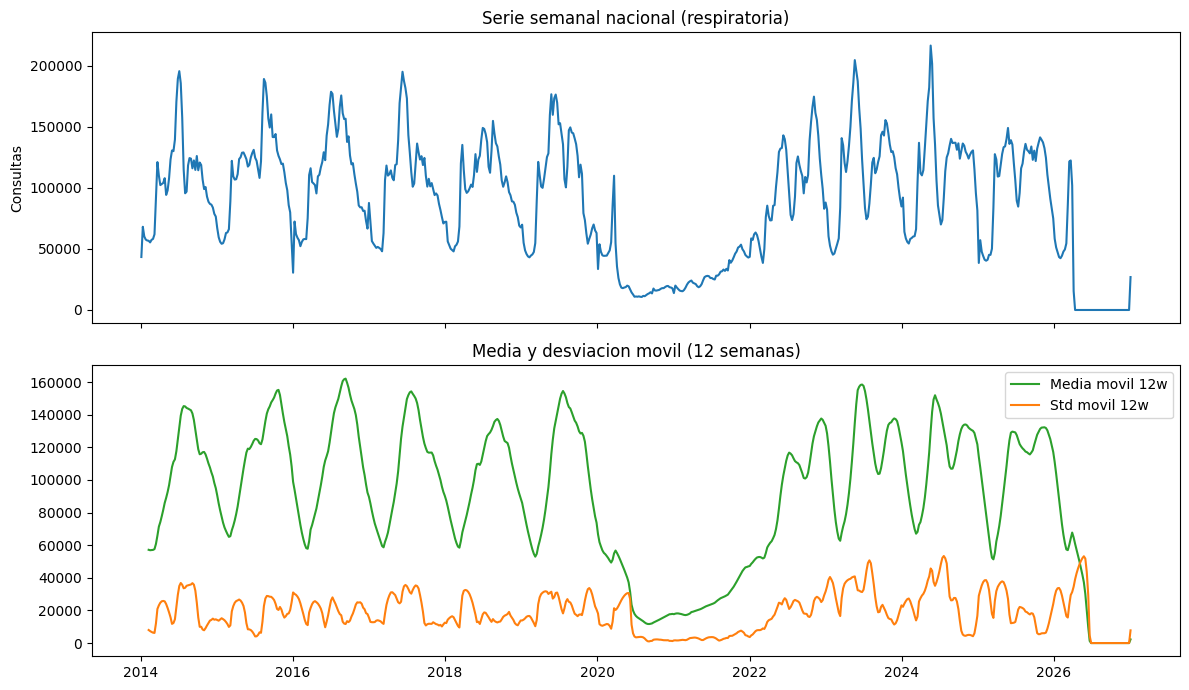

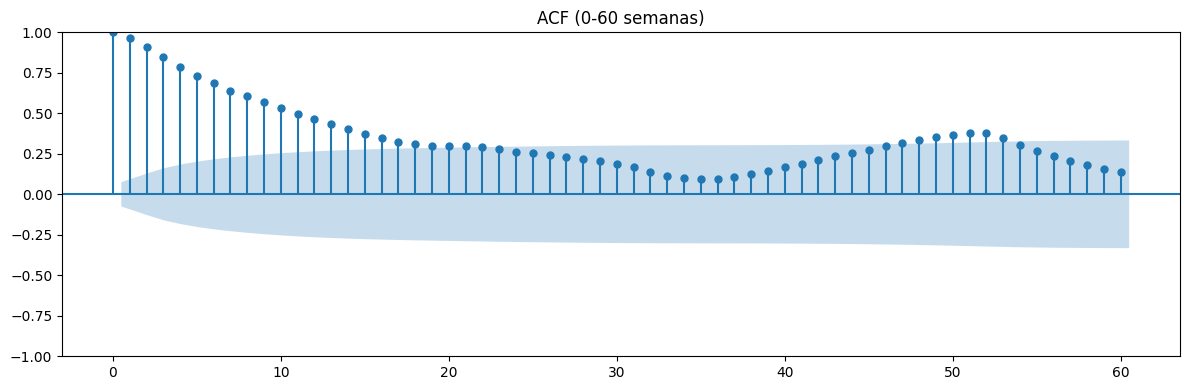

In [9]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

series = series.sort_index()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(series.index, series.values, color="tab:blue")
axes[0].set_title("Serie semanal nacional (respiratoria)")
axes[0].set_ylabel("Consultas")

roll_mean = series.rolling(12, min_periods=6).mean()
roll_std = series.rolling(12, min_periods=6).std()
axes[1].plot(series.index, roll_mean, color="tab:green", label="Media movil 12w")
axes[1].plot(series.index, roll_std, color="tab:orange", label="Std movil 12w")
axes[1].legend()
axes[1].set_title("Media y desviacion movil (12 semanas)")
plt.tight_layout()
plt.show()

# ACF on its own axis to avoid compression
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(series.dropna(), lags=60, ax=ax)
ax.set_title("ACF (0-60 semanas)")
plt.tight_layout()
plt.show()

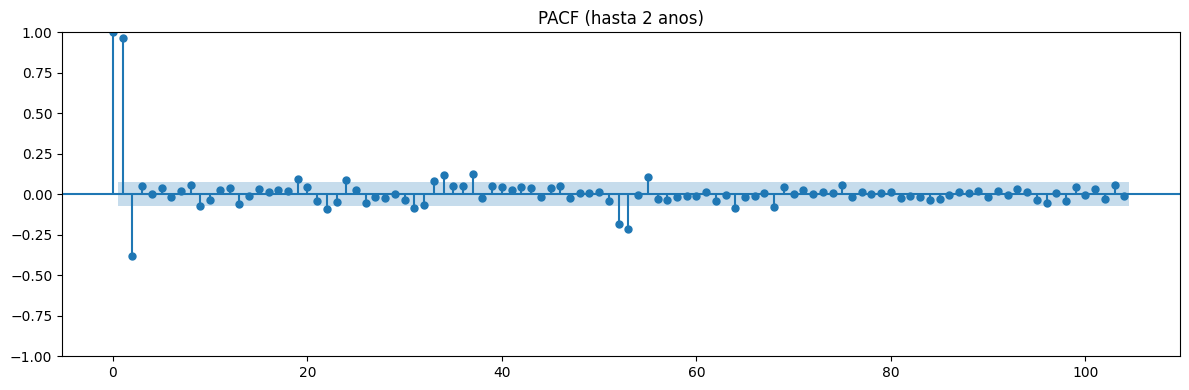

In [7]:
# PACF to see partial autocorrelation
fig, ax = plt.subplots(figsize=(12, 4))
plot_pacf(series.dropna(), lags=104, ax=ax, method="ywm")
ax.set_title("PACF (hasta 2 anos)")
plt.tight_layout()
plt.show()

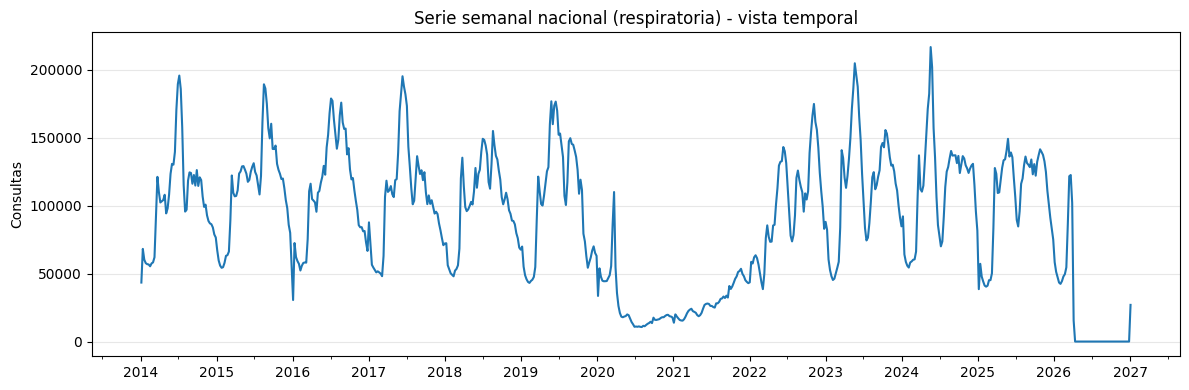

In [5]:
# Simple time-series view with yearly markers
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(series.index, series.values, color="tab:blue")
ax.set_title("Serie semanal nacional (respiratoria) - vista temporal")
ax.set_ylabel("Consultas")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

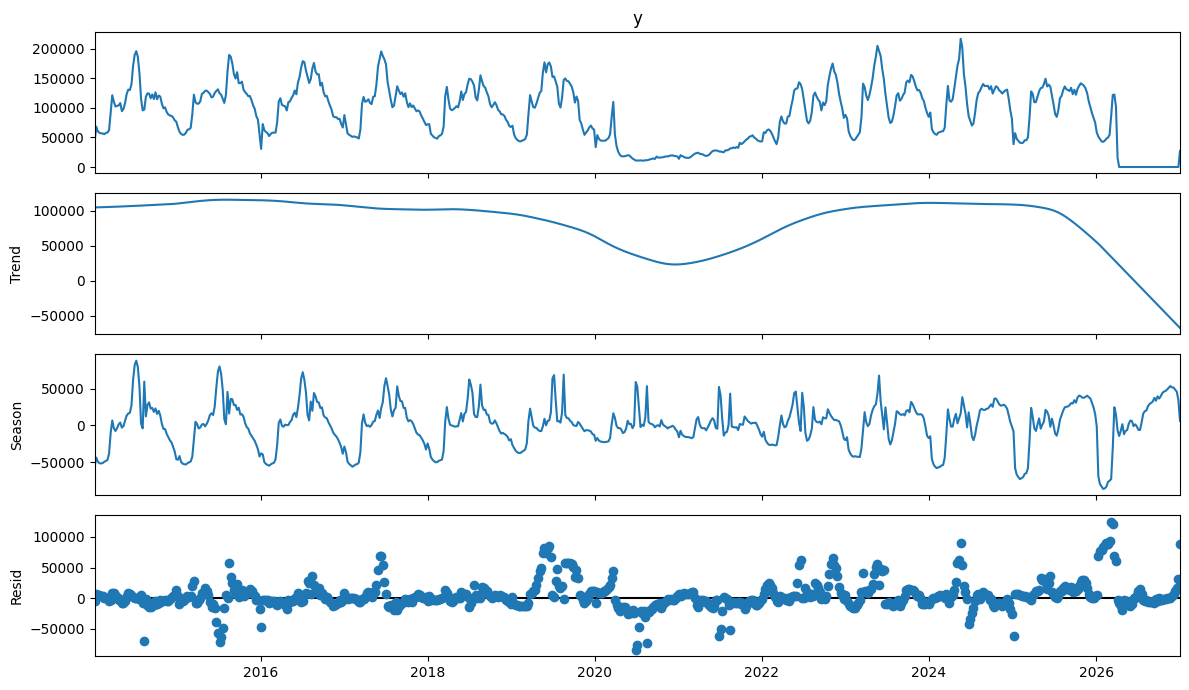

In [6]:
from statsmodels.tsa.seasonal import STL

# Decompose into trend/seasonal/residual (weekly seasonality ~ 52)
stl = STL(series, period=52, robust=True)
stl_res = stl.fit()

fig = stl_res.plot()
fig.set_size_inches(12, 7)
plt.tight_layout()
plt.show()

In [4]:
from statsmodels.tsa.stattools import adfuller, kpss

def stationarity_tests(x, label):
    x = x.dropna()
    adf_res = adfuller(x, autolag="AIC")
    kpss_res = kpss(x, regression="c", nlags="auto")
    return {
        "serie": label,
        "adf_stat": float(adf_res[0]),
        "adf_pvalue": float(adf_res[1]),
        "kpss_stat": float(kpss_res[0]),
        "kpss_pvalue": float(kpss_res[1]),
    }

tests = []
tests.append(stationarity_tests(series, "nivel"))

diff_1 = series.diff()
tests.append(stationarity_tests(diff_1, "d=1"))

diff_seasonal = series.diff(52)
tests.append(stationarity_tests(diff_seasonal, "D=1 (52w)"))

diff_both = series.diff(52).diff()
tests.append(stationarity_tests(diff_both, "d=1, D=1 (52w)"))

tests

/tmp/ipykernel_94331/3149276220.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(x, regression="c", nlags="auto")
/tmp/ipykernel_94331/3149276220.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(x, regression="c", nlags="auto")
/tmp/ipykernel_94331/3149276220.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(x, regression="c", nlags="auto")


[{'serie': 'nivel',
  'adf_stat': -4.583914773972489,
  'adf_pvalue': 0.00013828078034856922,
  'kpss_stat': 0.42782861683351564,
  'kpss_pvalue': 0.06516007895107084},
 {'serie': 'd=1',
  'adf_stat': -6.953365008769722,
  'adf_pvalue': 9.565954618522442e-10,
  'kpss_stat': 0.0354736805908983,
  'kpss_pvalue': 0.1},
 {'serie': 'D=1 (52w)',
  'adf_stat': -3.862999766458629,
  'adf_pvalue': 0.002324667303553658,
  'kpss_stat': 0.2888171889682841,
  'kpss_pvalue': 0.1},
 {'serie': 'd=1, D=1 (52w)',
  'adf_stat': -9.453923541712584,
  'adf_pvalue': 4.538391026569257e-16,
  'kpss_stat': 0.023510160679339052,
  'kpss_pvalue': 0.1}]

In [ ]:
import warnings
from itertools import product
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

# Small SARIMA grid search (kept compact to avoid long runtimes)
p_vals = [0, 1, 2]
d_vals = [0, 1]
q_vals = [0, 1]
P_vals = [0, 1]
D_vals = [0, 1]
Q_vals = [0, 1]
s = 52

results = []
for p, d, q, P, D, Q in product(p_vals, d_vals, q_vals, P_vals, D_vals, Q_vals):
    order = (p, d, q)
    seasonal_order = (P, D, Q, s)
    try:
        model = SARIMAX(
            series,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        fit = model.fit(disp=False)
        results.append({
            "order": order,
            "seasonal_order": seasonal_order,
            "aic": fit.aic,
            "bic": fit.bic,
        })
    except Exception:
        continue

import pandas as pd
grid = pd.DataFrame(results).sort_values("aic").reset_index(drop=True)
grid.head(10)